# XGBoost Model (No-leakage, With Automatic Tuning)



In [1]:
import os
import sys
import importlib
import pandas as pd
from xgboost import XGBClassifier

sys.path.append(os.path.abspath('..'))


import src.model_utils as model_utils
importlib.reload(model_utils)

evaluate_classifier = model_utils.evaluate_classifier
get_confusion_matrix_df = model_utils.get_confusion_matrix_df
load_encoded_splits = model_utils.load_encoded_splits
plot_metric_scorecards = model_utils.plot_metric_scorecards
plot_roc_curve = model_utils.plot_roc_curve
run_random_search = model_utils.run_random_search

In [2]:
DATA_DIR = '../data/'
X_train, y_train, X_val, y_val, X_test, y_test = load_encoded_splits(DATA_DIR, version="no-leakage")

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape}, y_val:   {y_val.shape}')
print(f'X_test:  {X_test.shape}, y_test:  {y_test.shape}')

Splits loaded successfully.
X_train: (60876, 32), y_train: (60876,)
X_val: (13045, 32), y_val: (13045,)
X_test: (13046, 32), y_test: (13046,)
X_train: (60876, 92), y_train: (60876,)
X_val:   (13045, 92), y_val:   (13045,)
X_test:  (13046, 92), y_test:  (13046,)


In [ ]:
SEED = 42

base_xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    random_state=SEED,
    n_jobs=-1,
)

param_distributions = {
    'n_estimators': [150, 250, 350, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6, 8],
    'min_child_weight': [1, 3, 5, 7],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0.0, 0.1, 0.2, 0.4],
}

search = run_random_search(
    estimator=base_xgb,
    param_distributions=param_distributions,
    X_train=X_train,
    y_train=y_train,
    n_iter=16,
    cv=3,
    scoring='f1',
    random_state=SEED,
    n_jobs=-1,
    verbose=1,
)

best_xgb = search.best_estimator_
print('Best params:', search.best_params_)
print(f'Best CV f1: {search.best_score_:.4f}')

Fitting 3 folds for each of 16 candidates, totalling 48 fits


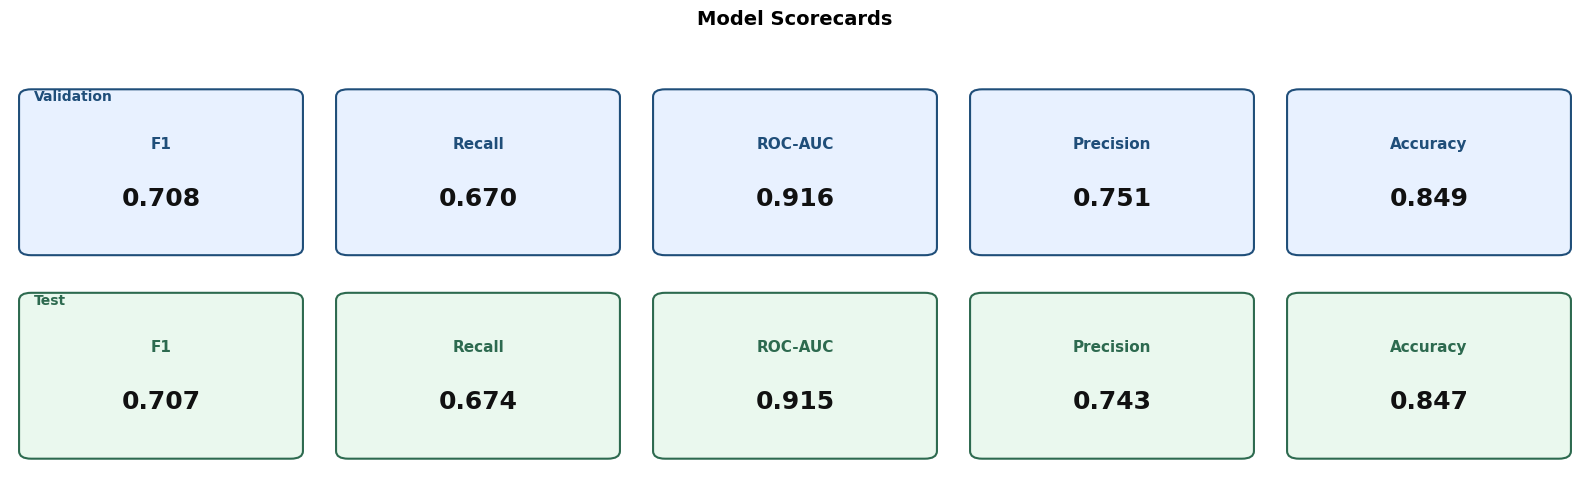

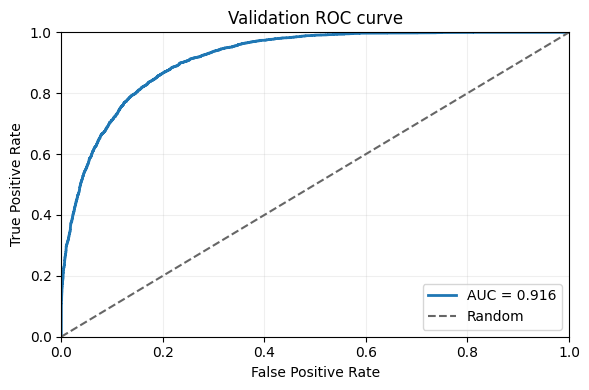

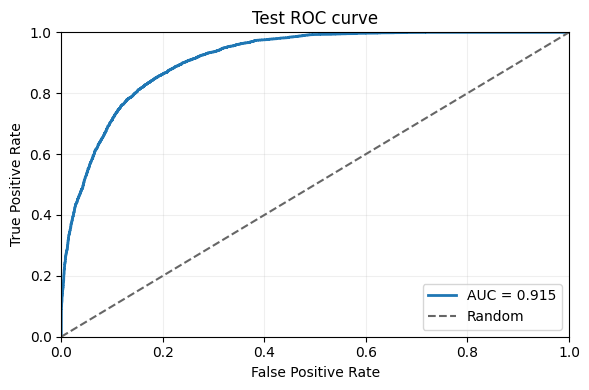

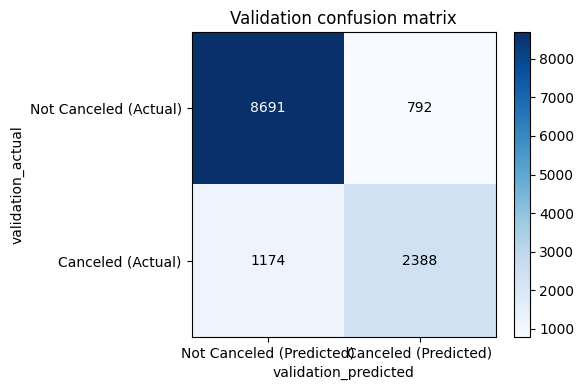

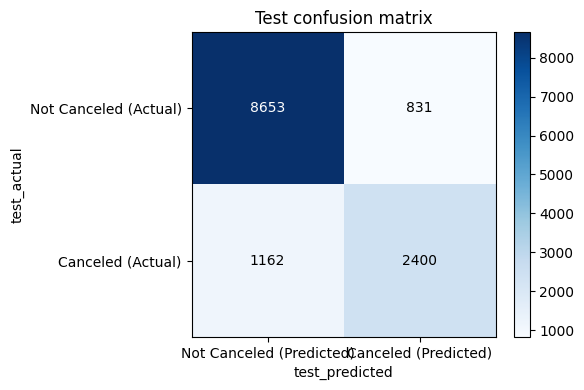

,split,accuracy,precision,recall,f1,roc_auc
0,validation,0.8493,0.7509,0.6704,0.7084,0.9159
1,test,0.8472,0.7428,0.6738,0.7066,0.9149


In [ ]:
val_results = evaluate_classifier(best_xgb, X_val, y_val, 'validation')
test_results = evaluate_classifier(best_xgb, X_test, y_test, 'test')
plot_metric_scorecards(val_results, test_results, notebook_name='10_xgboost_no_leakage.ipynb')
plot_roc_curve(best_xgb, X_val, y_val, 'validation', notebook_name='10_xgboost_no_leakage.ipynb')
plot_roc_curve(best_xgb, X_test, y_test, 'test', notebook_name='10_xgboost_no_leakage.ipynb')
val_cm = get_confusion_matrix_df(best_xgb, X_val, y_val, 'validation', notebook_name='10_xgboost_no_leakage.ipynb', plot=True)
test_cm = get_confusion_matrix_df(best_xgb, X_test, y_test, 'test', notebook_name='10_xgboost_no_leakage.ipynb', plot=True)

results_df = pd.DataFrame([val_results, test_results])
display(results_df.round(4))

In [ ]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_xgb.feature_importances_,
}).sort_values('importance', ascending=False)

display(importance_df.head(15))

,feature,importance
14,required_car_parking_spaces,0.108719
69,market_segment_Online TA,0.090787
86,deposit_type_Non Refund,0.082744
31,country_PRT,0.047573
29,agent_other,0.033501
22,agent_7,0.030793
19,agent_9,0.030414
90,customer_type_Transient,0.028519
15,total_of_special_requests,0.027352
20,agent_240,0.027002
